<a href="https://colab.research.google.com/github/mducdaf2/ai-knowledges/blob/main/NLP/Classification_VectorSpaces/preprocessing_nltk.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sentiment Analysis with Logistic Regression

In [31]:
import nltk
from nltk.corpus import twitter_samples
import matplotlib.pyplot as plt
from pathlib import Path
import random
import numpy as np
import os

## 0. Dataset
Tập dataset twitter từ NLTK được chia thành 2 loại positive và negative, mỗi loại chứa 5000 tweets

In [ ]:
nltk.corpus.sub

In [25]:
# Download
nltk.download("twitter_samples")

[nltk_data] Downloading package twitter_samples to /root/nltk_data...
[nltk_data]   Package twitter_samples is already up-to-date!


True

In [8]:
data_dir = Path('/content/data/corpora/twitter_samples')
list(data_dir.iterdir())

[PosixPath('/content/data/corpora/twitter_samples/tweets.20150430-223406.json'),
 PosixPath('/content/data/corpora/twitter_samples/positive_tweets.json'),
 PosixPath('/content/data/corpora/twitter_samples/README.md'),
 PosixPath('/content/data/corpora/twitter_samples/README.txt'),
 PosixPath('/content/data/corpora/twitter_samples/negative_tweets.json')]

Load text fields of positive and negative tweets

In [11]:
pos_tweets = twitter_samples.strings('positive_tweets.json')
neg_tweets = twitter_samples.strings('negative_tweets.json')
neg_tweets[:5]

['hopeless for tmr :(',
 "Everything in the kids section of IKEA is so cute. Shame I'm nearly 19 in 2 months :(",
 '@Hegelbon That heart sliding into the waste basket. :(',
 '“@ketchBurning: I hate Japanese call him "bani" :( :(”\n\nMe too',
 'Dang starting next week I have "work" :(']

In [12]:
print("Number of positive tweets:", len(pos_tweets))
print("Number of negative tweets:", len(neg_tweets))

Number of positive tweets: 5000
Number of negative tweets: 5000


In [13]:
# print positive in greeen
print('\033[92m' + pos_tweets[random.randint(0,5000)])

# print negative in red
print('\033[91m' + neg_tweets[random.randint(0,5000)])

@TotalPolicing We won't delve in to that here :)
hey christine, why so moody? :(


## 1. Preprocess raw text
Là bước cực kỳ quan trọng trong các dự án ML. Bao gồm cleaning và formatting data trước khi đưa vào thuật toán ML. Trong NLP có thể đề cập đến các bước chính sau:
- Tokenizing the string
- Lowercasing
- Removing stop words and punctuation
- Stemming

In [15]:
tweet = pos_tweets[2277]
print(tweet)

My beautiful sunflowers on a sunny Friday morning off :) #sunflowers #favourites #happy #Friday off… https://t.co/3tfYom0N1i


Sử dụng stopword có trong NLTK

In [26]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

Các thư viện cho việc preprocessing

In [23]:
import re           # Regular Expression
import string       # String operations

from nltk.corpus import stopwords           # stop words
from nltk.stem import PorterStemmer         # stemming
from nltk.tokenize import TweetTokenizer    # tokennizing

### Remove hyperlinks, twitter marks and styles
Xoá đi các phần tử như hashtags, retweet marks, hyperlinks,...

Sủ dụng `re`, định nghĩa pattern và sử dụng `re.sub()` để xoá pattern match bằng việc thay thế (substituting) với ký tự trống `''`.

In [18]:
print('\033[92m' + tweet)
print('\033[94m')

# remove old style retweet text "RT"
tweet2 = re.sub(r'^RT[\s]+', '', tweet)
print(tweet2)

# remove hyperlinks
tweet2 = re.sub(r'https?://[^\s\n\r]+', '', tweet2)
print(tweet2)

# remove hashtags, only hash # sign
tweet2 = re.sub(r'#', '', tweet2)
print(tweet2)

My beautiful sunflowers on a sunny Friday morning off :) #sunflowers #favourites #happy #Friday off… https://t.co/3tfYom0N1i

My beautiful sunflowers on a sunny Friday morning off :) #sunflowers #favourites #happy #Friday off… https://t.co/3tfYom0N1i
My beautiful sunflowers on a sunny Friday morning off :) #sunflowers #favourites #happy #Friday off… 
My beautiful sunflowers on a sunny Friday morning off :) sunflowers favourites happy Friday off… 


### Tokenize chuỗi
Hiểu đơn giản, tokenize là việc chia chuỗi thành các từ riêng lẻ mà không chứa khoảng cách (blanks) hoặc tab. Đồng thời chúng ta cũng chuyển các từ này về dạng lowercase.

In [19]:
print('\033[92m' + tweet2)
print('\033[94m')

tokenizer = TweetTokenizer(preserve_case=False, strip_handles=True, reduce_len=True)

# Tokenize tweets
tweet_tokens = tokenizer.tokenize(tweet2)

print()
print("Tokenize String:")
print(tweet_tokens)

My beautiful sunflowers on a sunny Friday morning off :) sunflowers favourites happy Friday off… 


Tokenize String:
['my', 'beautiful', 'sunflowers', 'on', 'a', 'sunny', 'friday', 'morning', 'off', ':)', 'sunflowers', 'favourites', 'happy', 'friday', 'off', '…']


### Remove stop words and punctuations
Tiếp theo là chúng ta phải xoá đi các stop words (and, or, at,...) và punctuation (dâu câu). Bởi vì các stop words thường không mang lại ý nghĩa cụ thể cho đoạn text

In [27]:
stopwords_en = stopwords.words('english')

print('Stop words:')
print(stopwords_en)

print('\nPunctuation')
print(string.punctuation)

Stop words:
['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", 'her', 'here', 'hers', 'herself', "he's", 'him', 'himself', 'his', 'how', 'i', "i'd", 'if', "i'll", "i'm", 'in', 'into', 'is', 'isn', "isn't", 'it', "it'd", "it'll", "it's", 'its', 'itself', "i've", 'just', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 'same', 'shan', "s

In [28]:
print()
print('\033[92m')
print(tweet_tokens)
print('\033[94m')

tweets_clean = []

for word in tweet_tokens: # Go through every word in your tokens list
    if (word not in stopwords_en and  # remove stopwords
        word not in string.punctuation):  # remove punctuation
        tweets_clean.append(word)

print('removed stop words and punctuation:')
print(tweets_clean)



['my', 'beautiful', 'sunflowers', 'on', 'a', 'sunny', 'friday', 'morning', 'off', ':)', 'sunflowers', 'favourites', 'happy', 'friday', 'off', '…']

removed stop words and punctuation:
['beautiful', 'sunflowers', 'sunny', 'friday', 'morning', ':)', 'sunflowers', 'favourites', 'happy', 'friday', '…']


### Stemming
Là quá trình xử lý để chuyển một từ về dạng tổng quát (general form), hay gọi là stem. Giúp giảm kích thước của vocabulary mà không làm mất đi nghĩa gốc của nó.

NLTK cung cấp nhiều module để thực hiện stemming, trong đó PorterStemmer sử dụng thuật toán Porter Stemming, lựa chọn stemming word về dạng prefix được sử dụng nhiều.

In [30]:
print()
print('\033[92m')
print(tweets_clean)
print('\033[94m')

# instantiate stemming class
stemmer = PorterStemmer()

tweets_stem = []

for word in tweets_clean:
    stem_word = stemmer.stem(word)
    tweets_stem.append(stem_word)

print("Stemmed words:")
print(tweets_stem)



['beautiful', 'sunflowers', 'sunny', 'friday', 'morning', ':)', 'sunflowers', 'favourites', 'happy', 'friday', '…']

Stemmed words:
['beauti', 'sunflow', 'sunni', 'friday', 'morn', ':)', 'sunflow', 'favourit', 'happi', 'friday', '…']


### Tổng hợp
Tổng hợp các bước tiền xử lý vào một hàm duy nhất để thuận tiện cho việc tái sử dụng.

In [35]:
def process_text(tweet):
    """Process tweet function.
    Input:
        tweet: a string containing a tweet
    Output:
        tweets_clean: a list of words containing the processed tweet

    """
    stemmer = PorterStemmer()
    stopwords_en = stopwords.words('english')

    # remove stock market tickers like $GE
    tweet = re.sub(r'\$\w*', '', tweet)
    # remove old style retweet text "RT"
    tweet = re.sub(r'^RT[\s]+', '', tweet)
    # remove hyperlinks
    tweet = re.sub(r'https?://[^\s\n\r]+', '', tweet)
    # remove hashtags
    # only removing the hash # sign from the word
    tweet = re.sub(r'#', '', tweet)

    # Tokenize
    tokenizer = TweetTokenizer(preserve_case=False, strip_handles=True, reduce_len=True)
    tweet_tokens = tokenizer.tokenize(tweet)

    tweets_clean = []
    for word in tweet_tokens:
        if (word not in stopwords_en and  # remove stopwords
                word not in string.punctuation):  # remove punctuation
            # tweets_clean.append(word)
            stem_word = stemmer.stem(word)  # stemming word
            tweets_clean.append(stem_word)
    return tweets_clean

In [38]:
print(pos_tweets[2])
print(process_text(pos_tweets[2]))

@DespiteOfficial we had a listen last night :) As You Bleed is an amazing track. When are you in Scotland?!
['listen', 'last', 'night', ':)', 'bleed', 'amaz', 'track', 'scotland']


## 2. Feature Extraction
Building and Visualizing word frequencies

### Build dataset

Đầu tiên, xây dựng lại dataset gồm các cặp $(x, y)$ trong đó:
- $x$ là một tweet
- $y$ ứng với label positive / negative tương ứng là 0 / 1.

In [32]:
# Concat tweets
tweets = pos_tweets + neg_tweets

# Create labels
pos_labels = np.ones(shape=(len(pos_tweets)))
neg_labels = np.zeros(shape=(len(neg_tweets)))

# Concat label:
labels = np.concat([pos_labels, neg_labels])
print("Number of tweets:", len(tweets))
print("Label shape:", labels.shape)

Number of tweets: 10000
Label shape: (10000,)


### Word frequency dictionary
Mục tiêu: xây dựng một dictionary chứa các cặp `(key: value)`, trong đó:
- `key`: tuple `(word, sentiment)`, ví dụ: `(happy, 1)`. Các word lấy trong vocabulary.
- `value`: giá trị frequencies của cặp trên, tức là số lần xuất hiện của word trong các câu có sentiment tương ứng.

In [42]:
freqs = {}

# Chuyển np.array về dạng list vì zip yêu cầu một iterable
labels_list = labels.tolist()

for y, tweet in zip(labels_list, tweets):
    for word in process_text(tweet):
        pair = (word, y)
        freqs[pair] = freqs.get(pair, 0) + 1

In [43]:
# check data type
print(f'type(freqs) = {type(freqs)}')

# check length of the dictionary
print(f'len(freqs) = {len(freqs)}')

type(freqs) = <class 'dict'>
len(freqs) = 13141


In [47]:
sorted(freqs.items(), key=lambda x: x[1], reverse=True)[:10]

[((':(', 0.0), 4584),
 ((':)', 1.0), 3691),
 ((':-)', 1.0), 701),
 ((':d', 1.0), 658),
 (('thank', 1.0), 643),
 ((':-(', 0.0), 501),
 (('follow', 1.0), 447),
 (('love', 1.0), 401),
 (('...', 0.0), 332),
 (('miss', 0.0), 301)]

### Tạo dataset
Với mỗi câu `tweet` qua bước `process_text` ta thu được các clean tokens. Lấy các token này dò vào `freqs` ta sẽ thu được tần suất tương ứng của token đó trong các câu positive và negative.

In [54]:
print(tweets[0])
clean_tokens = process_text(tweets[0])
print(clean_tokens)

print()
data = [] # Chứa tương ứng: [word, pos, neg]

for word in clean_tokens:
    pos = freqs.get((word, 1), 0)
    neg = freqs.get((word, 0), 0)
    data.append([word, pos, neg])
data

#FollowFriday @France_Inte @PKuchly57 @Milipol_Paris for being top engaged members in my community this week :)
['followfriday', 'top', 'engag', 'member', 'commun', 'week', ':)']



[['followfriday', 25, 0],
 ['top', 32, 6],
 ['engag', 7, 0],
 ['member', 16, 6],
 ['commun', 33, 2],
 ['week', 83, 56],
 [':)', 3691, 2]]

Khi đó, với mỗi tweet chúng ta có thể tính được 2 feature:
- `positive`: Tổng positive freqs của các clean word trong tweet.
- `negative`: Tổng negative freqs của các clean word trong tweet.

In [55]:
def feature_extraction(tweet, freqs):
    pos_freq = 0
    neg_freq = 0
    for w in process_text(tweet):
        pos_freq += freqs.get((w, 1), 0)
        neg_freq += freqs.get((w, 0), 0)
    return pos_freq, neg_freq

In [56]:
feature_extraction(tweets[0], freqs)

(3887, 72)

In [70]:
data = []
for label, tweet in zip(labels_list, tweets):
    pos_freq, neg_freq = feature_extraction(tweet, freqs)
    data.append([pos_freq, neg_freq, label])

print(len(data))
print(data[:2])

10000
[[3887, 72, 1.0], [4613, 518, 1.0]]


Tạo file .csv lưu dataset

In [73]:
import pandas as pd

df = pd.DataFrame(data, columns=['positive', 'negative', 'sentiment'])

# Thêm cột bias (cho việc train logistic regression)
df['bias'] = 1.

# Sắp xếp lại thứ tự cột
df = df[['bias', 'positive', 'negative', 'sentiment']]

df.head()

,bias,positive,negative,sentiment
0,1.0,3887,72,1.0
1,1.0,4613,518,1.0
2,1.0,3883,161,1.0
3,1.0,3712,4,1.0
4,1.0,4038,281,1.0


In [74]:
df.describe()

,bias,positive,negative,sentiment
count,10000.0,10000.000000,10000.000000,10000.000000
mean,1.0,1789.966800,2407.457900,0.500000
std,0.0,2052.050134,2519.654901,0.500025
min,1.0,0.000000,0.000000,0.000000
25%,1.0,145.000000,171.000000,0.000000
50%,1.0,714.000000,728.500000,0.500000
75%,1.0,3835.000000,4768.000000,1.000000
max,1.0,44300.000000,27802.000000,1.000000


In [75]:
df.to_csv('data.csv', index=False)

## 3. Logistic Regression Model

### Data preparation
Sử dụng dataset được tạo ra từ bước trước.

In [76]:
df = pd.read_csv('data.csv')
df.head()

,bias,positive,negative,sentiment
0,1.0,3887,72,1.0
1,1.0,4613,518,1.0
2,1.0,3883,161,1.0
3,1.0,3712,4,1.0
4,1.0,4038,281,1.0


Chuyển data sang numpy array

In [79]:
data_np = df.to_numpy()
print(data_np.shape)
print(data_np.dtype)
print(data_np[:3, :])

(10000, 4)
float64
[[1.000e+00 3.887e+03 7.200e+01 1.000e+00]
 [1.000e+00 4.613e+03 5.180e+02 1.000e+00]
 [1.000e+00 3.883e+03 1.610e+02 1.000e+00]]


In [80]:
# Tách thành data và label
X, y = data_np[:, :-1], data_np[:, -1]

# Thêm cột
print(X.shape, y.shape)

(10000, 3) (10000,)


Chia tập train / val

In [82]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y      # Giữ tỷ lệ nhãn giống nhau giữa train / test
)

print(X_train.shape, y_train.shape)

(8000, 3) (8000,)


Text(0, 0.5, 'Negative')

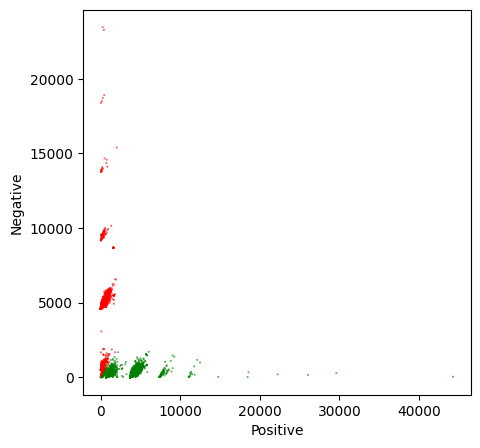

In [84]:
# Plot the samples using columns 1 and 2 of the matrix
fig, ax = plt.subplots(figsize = (5, 5))

colors = ['red', 'green']

# Color based on the sentiment Y
ax.scatter(X_train[:,1], X_train[:,2], c=[colors[int(k)] for k in y_train], s = 0.1)  # Plot a dot for each pair of words
plt.xlabel("Positive")
plt.ylabel("Negative")

### Logistic Model

Sử dụng Logistic Regression cho bài toán phân loại nhị phân. Với công thức:
$$ h(x^{(i)}, \theta) = \frac{1}{1 + \exp(-\theta^T x^{(i)})} $$

In [85]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model.fit(X_train, y_train)

LogisticRegression()

In [86]:
y_pred = model.predict(X_test)              # nhãn dự đoán (0 hoặc 1)
y_pred_proba = model.predict_proba(X_test)   # xác suất cho từng lớp

print(y_pred[:10])
print(y_pred_proba[:5])   # cột 0 = P(class=0), cột 1 = P(class=1)

[0. 1. 0. 1. 0. 0. 0. 1. 0. 1.]
[[1.00000000e+00 1.05764026e-20]
 [2.52464716e-13 1.00000000e+00]
 [1.00000000e+00 5.94497444e-39]
 [2.51576537e-13 1.00000000e+00]
 [1.00000000e+00 1.11551488e-19]]


Đánh giá mô hình

In [87]:
from sklearn.metrics import accuracy_score

acc = accuracy_score(y_test, y_pred)
acc

0.9945

[[996   4]
 [  7 993]]


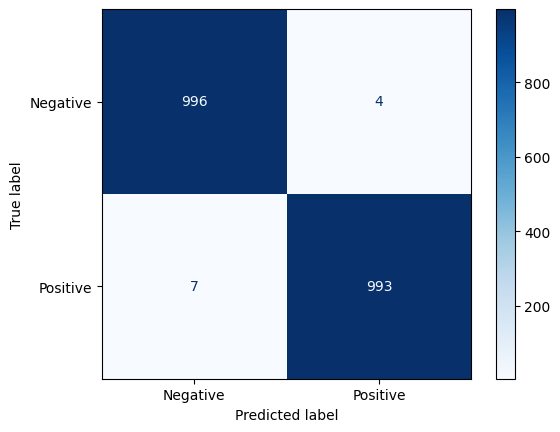

In [91]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)
print(cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Negative", "Positive"])
disp.plot(cmap="Blues")
plt.show()

Precision, Recall, F1-Score

In [93]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred, target_names=["Negative", "Positive"]))

              precision    recall  f1-score   support

    Negative       0.99      1.00      0.99      1000
    Positive       1.00      0.99      0.99      1000

    accuracy                           0.99      2000
   macro avg       0.99      0.99      0.99      2000
weighted avg       0.99      0.99      0.99      2000



ROC-AUC: 0.9996


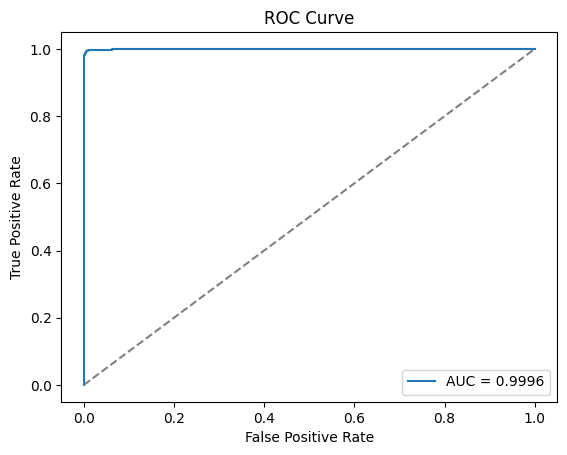

In [94]:
from sklearn.metrics import roc_auc_score, roc_curve

auc = roc_auc_score(y_test, y_pred_proba[:, 1])
print(f"ROC-AUC: {auc:.4f}")

fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba[:, 1])

plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")  # đường baseline (random guess)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [96]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(model, X_train, y_train, cv=cv, scoring="accuracy")

print("Accuracy mỗi fold:", scores)
print(f"Trung bình: {scores.mean():.4f} (+/- {scores.std():.4f})")

Accuracy mỗi fold: [0.99875  0.99375  0.994375 0.993125 0.9925  ]
Trung bình: 0.9945 (+/- 0.0022)


## 5. Inference

In [120]:
example = "I am very sad :), I loss my girl friend :("
print(example)

# Data process
clean_tokens = process_text(example)
print(clean_tokens)

# Feature Extraction
x = feature_extraction(example, freqs)
print(x)

# Build input model
input = [1.] + list(x)
input = np.array(input, ndmin=2)
print(input)

# Predict
pred = model.predict(input)
pred_proba = model.predict_proba(input)
print(pred)
print(pred_proba)

I am very sad :), I loss my girl friend :(
['sad', ':)', 'loss', 'girl', 'friend', ':(']
(3806, 4779)
[[1.000e+00 3.806e+03 4.779e+03]]
[0.]
[[9.99999883e-01 1.17388742e-07]]


## References
- NLTK (Natural language Toolkit) in PyPI: https://pypi.org/project/nltk/
- Nội dung lấy cảm hứng từ bài lab Coursera.
- Documentation NLTK: https://www.nltk.org/